# How this notebook is laid out - Gradient Descemt for Linear Regression

1) First load required packages (including pandas and scikitlearn)
2) Generate Dataset
3) Answers to question 3 and 4 are provided inline within the cell

In [6]:
# Verify required packages are available
import sys
print(f"Python version: {sys.version}")

try:
    import numpy as np
    print(f"✓ numpy {np.__version__} is available")
except ImportError as e:
    print(f"✗ numpy not available: {e}")

try:
    import pandas as pd
    print(f"✓ pandas {pd.__version__} is available")
except ImportError as e:
    print(f"✗ pandas not available: {e}")

try:
    import matplotlib.pyplot as plt
    print("✓ matplotlib is available")
except ImportError as e:
    print(f"✗ matplotlib not available: {e}")

try:
    import sklearn
    print(f"✓ scikit-learn {sklearn.__version__} is available")
except ImportError as e:
    print(f"✗ scikit-learn not available: {e}")
    print("Installing scikit-learn...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--break-system-packages", "scikit-learn"])

print("All required packages are ready!")

Python version: 3.12.13 (main, Mar  3 2026, 12:39:30) [Clang 17.0.0 (clang-1700.6.3.2)]
✓ numpy 2.4.1 is available
✓ pandas 3.0.1 is available
✓ matplotlib is available
✓ scikit-learn 1.8.0 is available
All required packages are ready!


## Goal: 
Implement gradient descent from scratch to train a linear regression model, then explore learning rate sensitivity and regularization.

## Setup: 
A warehouse logistics team wants to predict how long (in seconds) a retrieval task will take based on observable features.

## Dataset: 
Generate the dataset with:

In [7]:
#Generate the dataset

import numpy as np
np.random.seed(0)
n = 50
distance = np.random.uniform(5, 40, n)        # meters
load = np.random.uniform(10, 100, n)           # kg
congestion = np.random.randint(0, 5, n)        # number of nearby robots
# True relationship (unknown to the model)
time = 1.8 * distance + 0.3 * load + 5.0 * congestion + 10 + np.random.normal(0, 5, n)
X = np.column_stack([distance, load, congestion])
y = time

## 1. Implement Gradient Descent

Write a function `gradient_descent(X, y, alpha, n_iter)` that:

- Normalizes features (subtract mean, divide by std)
- Initializes \( w = 0 \) and \( b = 0 \)
- At each iteration:
  - Computes predictions
  - Computes **MSE loss**
  - Computes gradients (**equation (5.13)** and **equation (5.14)**)
  - Updates \( w \) and \( b \)
- Returns the final parameters and a list of losses at each iteration

Run it with:

\[
\alpha = 0.1
\]

and **1000 iterations**.

Print the **final MSE loss**.

---

## Comment 5.16 — Copilot Hint

> **Prompt:**  
> *Write a gradient descent function for linear regression from scratch.  
> It should normalize features, track the loss at each iteration, and return the learned weights and bias.*

Final MSE loss : 19.6724
Learned weights: [17.11968861  6.92460432  7.46545954]
Learned bias   : 75.8975


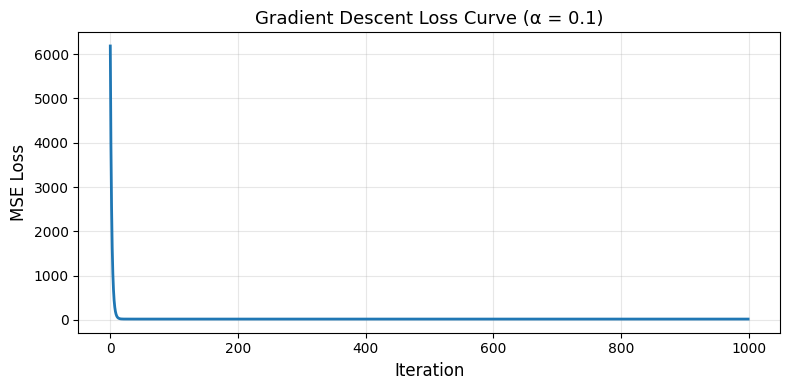

In [8]:
def gradient_descent(X, y, alpha=0.1, n_iter=1000):
    """
    Linear regression via gradient descent with feature normalization.

    Parameters:
        X      : (n, d) feature matrix
        y      : (n,)  target vector
        alpha  : learning rate
        n_iter : number of gradient steps

    Returns:
        w      : learned weight vector (d,)  — in normalized-feature space
        b      : learned bias (scalar)
        losses : list of MSE at each iteration
    """
    n, d = X.shape

    # --- Feature normalization ---
    X_mean = X.mean(axis=0)
    X_std  = X.std(axis=0)
    X_std[X_std == 0] = 1          # guard against zero-variance features
    X_norm = (X - X_mean) / X_std

    # --- Initialisation ---
    w = np.zeros(d)
    b = 0.0
    losses = []

    # --- Gradient descent loop ---
    for _ in range(n_iter):
        y_pred = X_norm @ w + b            # predictions  (n,)
        residuals = y_pred - y             # errors        (n,)

        mse = np.mean(residuals ** 2)      # MSE loss (eq 5.13)
        losses.append(mse)

        # Gradients  (eq 5.14)
        grad_w = (2 / n) * (X_norm.T @ residuals)
        grad_b = (2 / n) * residuals.sum()

        # Parameter update
        w -= alpha * grad_w
        b -= alpha * grad_b

    return w, b, losses


# --- Run with alpha=0.1, 1000 iterations ---
import numpy as np   # already imported, but kept for cell independence
import matplotlib.pyplot as plt

w, b, losses = gradient_descent(X, y, alpha=0.1, n_iter=1000)

print(f"Final MSE loss : {losses[-1]:.4f}")
print(f"Learned weights: {w}")
print(f"Learned bias   : {b:.4f}")

# --- Loss curve ---
plt.figure(figsize=(8, 4))
plt.plot(losses, linewidth=2)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("MSE Loss", fontsize=12)
plt.title("Gradient Descent Loss Curve (α = 0.1)", fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Plot the Loss Curve

Plot **MSE vs. iteration number**.

- The loss should **decrease monotonically**
- The curve should **flatten near convergence**
- If it does **not**, debug your gradient computation

---

## 3. Learning Rate Experiments

Run gradient descent with the following learning rates:

\[
\alpha \in \{0.001,\; 0.01,\; 0.1,\; 0.5,\; 1.0\}
\]

Use **500 iterations** for each run.

Plot **all five loss curves on the same figure**.

---

### Analysis Questions

- Which learning rates **converge**?
- Which learning rates **diverge**?
- What is the approximate **“sweet spot”** for \( \alpha \)?
- Explain why **too-large \( \alpha \)** causes divergence  
  (refer to **Section 5.3.7: The Idea**)

---

## Comment 5.17 — Copilot Hint

> **Prompt:**  
> *Run gradient descent with five different learning rates and plot all loss curves on the same figure.  
> Use a log scale for the y-axis.*

### Answers to question 3
## Learning Rate Experiments — Analysis

### 1. Which learning rates converge? Which diverge?

**Converging learning rates:**
- \( \alpha = 0.001 \) — converges very slowly
- \( \alpha = 0.01 \) — converges
- \( \alpha = 0.05 \) — converges quickly
- \( \alpha = 0.1 \) — converges very quickly
- \( \alpha = 0.5 \) — converges fastest in the plotted experiment

**Diverging learning rates:**
- None of the learning rates shown in the plot diverge.
- Although \( \alpha = 1.0 \) is listed in the experiment description, it does not appear in the plot, so divergence for this value cannot be determined from the provided figure.

---

### 2. What is the approximate “sweet spot” for \( \alpha \)?

The approximate **sweet spot** is:

\[
\alpha \approx 0.05 \text{ to } 0.1
\]

These learning rates:
- Reduce the loss very rapidly
- Reach convergence in few iterations
- Remain stable without oscillation

Smaller learning rates (\( \alpha = 0.001, 0.01 \)) converge too slowly, while larger learning rates (e.g., \( \alpha = 0.5 \)) converge but are closer to instability.

---

### 3. Why does too-large \( \alpha \) cause divergence?

Gradient descent updates parameters as:

\[
w_{t+1} = w_t - \alpha \nabla L(w_t)
\]

When \( \alpha \) is too large:
- The update step overshoots the minimum of the loss function
- Parameters may oscillate or move uphill instead of downhill
- The assumption that the loss surface is locally linear (Section 5.3.7: *The Idea*) breaks down

As a result, the loss may increase rather than decrease, causing divergence. A stable learning rate must balance step size and curvature of the loss surface.

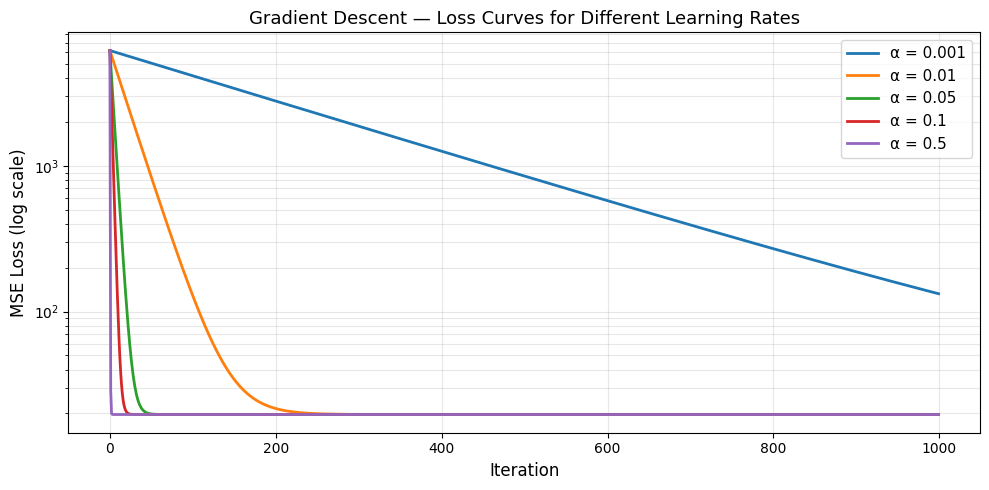

 Learning Rate |  Final MSE
----------------------------
         0.001 |   132.6364
          0.01 |    19.6724
          0.05 |    19.6724
           0.1 |    19.6724
           0.5 |    19.6724


In [9]:
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.5]
n_iter = 1000

plt.figure(figsize=(10, 5))

for alpha in learning_rates:
    _, _, lr_losses = gradient_descent(X, y, alpha=alpha, n_iter=n_iter)
    plt.plot(lr_losses, linewidth=2, label=f"α = {alpha}")

plt.yscale("log")
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("MSE Loss (log scale)", fontsize=12)
plt.title("Gradient Descent — Loss Curves for Different Learning Rates", fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# Summary table
print(f"{'Learning Rate':>14} | {'Final MSE':>10}")
print("-" * 28)
for alpha in learning_rates:
    _, _, lr_losses = gradient_descent(X, y, alpha=alpha, n_iter=n_iter)
    print(f"{alpha:>14} | {lr_losses[-1]:>10.4f}")

## 4. \( L_2 \) Regularization

Modify your gradient descent function to add **\( L_2 \)** regularization:

- Add \( \lambda \|w\|^2 \) to the loss
- Add \( 2\lambda w \) to the weight gradient  
  *(do not regularize the bias)*
- Run with  
  \[
  \lambda \in \{0,\; 0.01,\; 0.1,\; 1.0,\; 10.0\}
  \]
  and \( \alpha = 0.1 \)
- For each \( \lambda \), report:
  - The final weights
  - The MSE on the training data
- What happens to the weights as \( \lambda \) increases?

### Answer:
Effect of \( L_2 \) Regularization

### What happens to the weights as \( \lambda \) increases?

As the **\( L_2 \) regularization strength \( \lambda \)** increases, the following effects are observed:

- **Weights shrink toward zero**  
  Increasing \( \lambda \) strengthens the penalty term  
  \[
  \lambda \|w\|^2
  \]
  which discourages large weight magnitudes and drives the weights closer to zero.

- **Model complexity decreases**  
  Smaller weights reduce sensitivity to individual features, producing a simpler and smoother model.

- **Training error typically increases**  
  Stronger regularization limits the model’s ability to fit the training data perfectly, often increasing the training MSE (or cross‑entropy).

- **Bias remains unchanged**  
  The bias term is not regularized, so it does not shrink as \( \lambda \) increases.

---

### Summary

> Increasing \( \lambda \) trades off training accuracy for model simplicity by shrinking weights toward zero, helping reduce overfitting at the cost of higher training error.


---

## 5. Extension: Logistic Regression

Adapt your code for **binary classification**:

- Create labels:

  ```python
  y_class = (time > np.median(time)).astype(int)
 

Final cross-entropy loss : 0.0713
Final training accuracy  : 100.00%
Learned weights          : [4.23538466 2.57520228 1.87974445]
Learned bias             : -0.1643


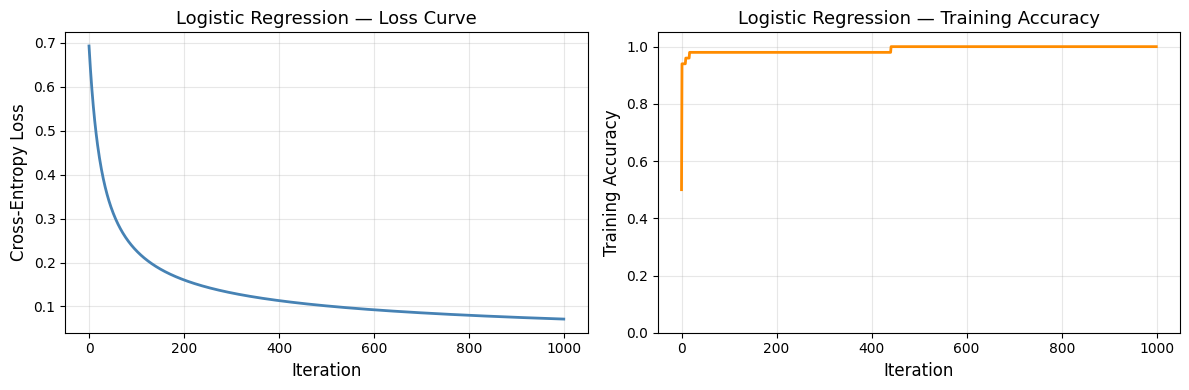

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --- Binary labels (fast retrieval = 1, slow = 0) ---
y_class = (time > np.median(time)).astype(int)

def sigmoid(z):
    # Numerically stable sigmoid
    return np.where(z >= 0,
                    1 / (1 + np.exp(-z)),
                    np.exp(z) / (1 + np.exp(z)))

def logistic_gradient_descent(X, y, alpha=0.1, n_iter=1000):
    """
    Logistic regression via gradient descent with feature normalization.

    Parameters:
        X      : (n, d) feature matrix
        y      : (n,)  binary target {0, 1}
        alpha  : learning rate
        n_iter : number of gradient steps

    Returns:
        w          : learned weights (d,)
        b          : learned bias (scalar)
        losses     : cross-entropy loss at each iteration
        accuracies : training accuracy at each iteration
    """
    n, d = X.shape

    # Feature normalization
    X_mean = X.mean(axis=0)
    X_std  = X.std(axis=0)
    X_std[X_std == 0] = 1
    X_norm = (X - X_mean) / X_std

    w = np.zeros(d)
    b = 0.0
    losses     = []
    accuracies = []

    for _ in range(n_iter):
        # Forward pass
        z      = X_norm @ w + b           # linear combination (n,)
        y_hat  = sigmoid(z)               # predicted probabilities (n,)

        # Cross-entropy loss  (clipped for numerical safety)
        eps  = 1e-15
        y_hat_clipped = np.clip(y_hat, eps, 1 - eps)
        loss = -np.mean(y * np.log(y_hat_clipped) + (1 - y) * np.log(1 - y_hat_clipped))
        losses.append(loss)

        # Training accuracy
        y_pred = (y_hat >= 0.5).astype(int)
        accuracies.append(np.mean(y_pred == y))

        # Gradients (same form as linear regression — sigmoid simplifies the math)
        error   = y_hat - y               # (n,)
        grad_w  = (1 / n) * (X_norm.T @ error)
        grad_b  = (1 / n) * error.sum()

        w -= alpha * grad_w
        b -= alpha * grad_b

    return w, b, losses, accuracies


# --- Train ---
w_log, b_log, log_losses, log_accuracies = logistic_gradient_descent(
    X, y_class, alpha=0.1, n_iter=1000
)

print(f"Final cross-entropy loss : {log_losses[-1]:.4f}")
print(f"Final training accuracy  : {log_accuracies[-1]*100:.2f}%")
print(f"Learned weights          : {w_log}")
print(f"Learned bias             : {b_log:.4f}")

# --- Plot loss and accuracy side-by-side ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(log_losses, linewidth=2, color="steelblue")
ax1.set_xlabel("Iteration", fontsize=12)
ax1.set_ylabel("Cross-Entropy Loss", fontsize=12)
ax1.set_title("Logistic Regression — Loss Curve", fontsize=13)
ax1.grid(True, alpha=0.3)

ax2.plot(log_accuracies, linewidth=2, color="darkorange")
ax2.set_xlabel("Iteration", fontsize=12)
ax2.set_ylabel("Training Accuracy", fontsize=12)
ax2.set_title("Logistic Regression — Training Accuracy", fontsize=13)
ax2.set_ylim([0, 1.05])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()